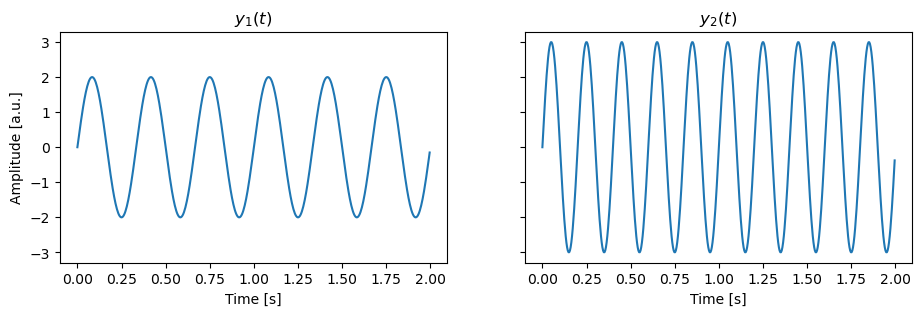

In [18]:

import numpy as np
from matplotlib import pyplot as plt

fs = 250
dur=2
t = np.linspace(0, dur, fs*dur, endpoint=False)
y1 = 2 * np.sin(2* np.pi * 3 * t)
y2 = 3 * np.sin(2* np.pi * 5 * t)

fig, ax = plt.subplots(1, 2, figsize=(11, 3), sharex=True, sharey=True)
ax[0].plot(t, y1)
ax[1].plot(t, y2)
ax[0].set(xlabel="Time [s]", ylabel="Amplitude [a.u.]", title="$y_1(t)$")
ax[1].set(xlabel="Time [s]", title="$y_2(t)$");

Consider two sine waves of different frequency and amplitude:


$y_1(t) = 2 \sin(2\pi \cdot 3 \cdot t)$

$y_2(t) = 3 \sin(2\pi \cdot 5 \cdot t)$

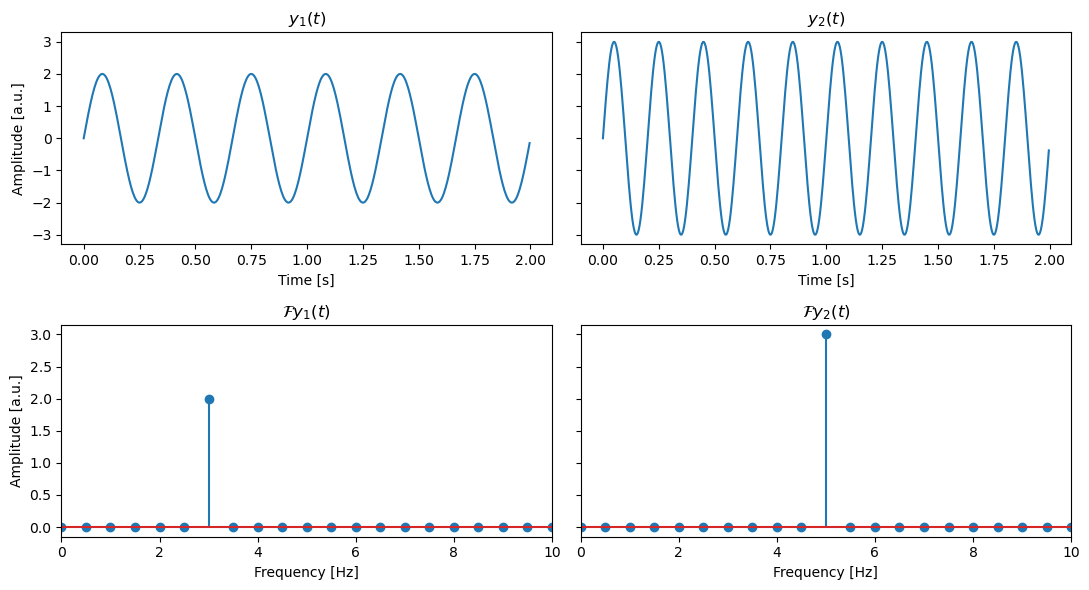

In [19]:
freq = np.fft.fftfreq(len(t), 1/fs)[:len(t)//2]
fft_y1 = np.abs(np.fft.fft(y1))[:len(t)//2] * 2/len(t)  # amplitude spectrum
fft_y2 = np.abs(np.fft.fft(y2))[:len(t)//2] * 2/len(t)

fig, ax = plt.subplots(2, 2, sharex="row", sharey="row", figsize=(11, 6))
ax[0, 0].plot(t, y1)
ax[0, 1].plot(t, y2)
ax[0, 0].set(xlabel="Time [s]", ylabel="Amplitude [a.u.]", title="$y_1(t)$")
ax[0, 1].set(xlabel="Time [s]", title="$y_2(t)$");
ax[1, 0].stem(freq, fft_y1)
ax[1, 1].stem(freq, fft_y2)
ax[1, 0].set(xlim=(0,10), xlabel="Frequency [Hz]", ylabel="Amplitude [a.u.]", title="$\mathcal{F}{y_1(t)}$")
ax[1, 1].set(xlim=(0,10), xlabel="Frequency [Hz]", title="$\mathcal{F}{y_2(t)}$")
plt.tight_layout()

The **Fourier transform** allows us to represent and visualize these signals in the **frequency domain**.

In a frequency spectrum, the x-axis represents frequency and the y-axis amplitude, i.e. how strongly a given frequency is represented in the signal.

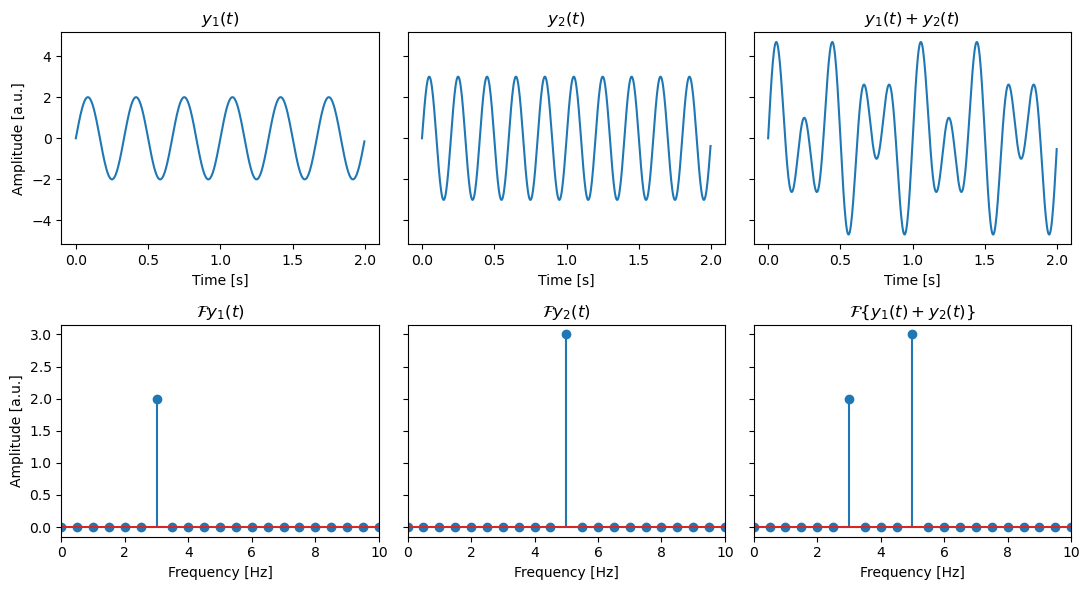

In [20]:
fft_y1y2 = np.abs(np.fft.fft(y1+y2))[:len(t)//2] * 2/len(t)  # amplitude spectrum

fig, ax = plt.subplots(2, 3, sharex="row", sharey="row", figsize=(11, 6))
ax[0, 0].plot(t, y1)
ax[0, 1].plot(t, y2)
ax[0, 2].plot(t, y1+y2)
ax[0, 0].set(xlabel="Time [s]", ylabel="Amplitude [a.u.]", title="$y_1(t)$")
ax[0, 1].set(xlabel="Time [s]", title="$y_2(t)$");
ax[0, 2].set(xlabel="Time [s]", title="$y_1(t)+y_2(t)$");
ax[1, 0].stem(freq, fft_y1)
ax[1, 1].stem(freq, fft_y2)
ax[1, 2].stem(freq, fft_y1y2)
ax[1, 0].set(xlim=(0,10), xlabel="Frequency [Hz]", ylabel="Amplitude [a.u.]", title="$\mathcal{F}{y_1(t)}$")
ax[1, 1].set(xlim=(0,10), xlabel="Frequency [Hz]", title="$\mathcal{F}{y_2(t)}$")
ax[1, 2].set(xlim=(0,10), xlabel="Frequency [Hz]", title="$\mathcal{F}\{y_1(t) + y_2(t)\}$")
plt.tight_layout()

Adding two signals in the time domain also adds their frequency spectra

It can be **easier to characterize** a signal in the frequency domain.

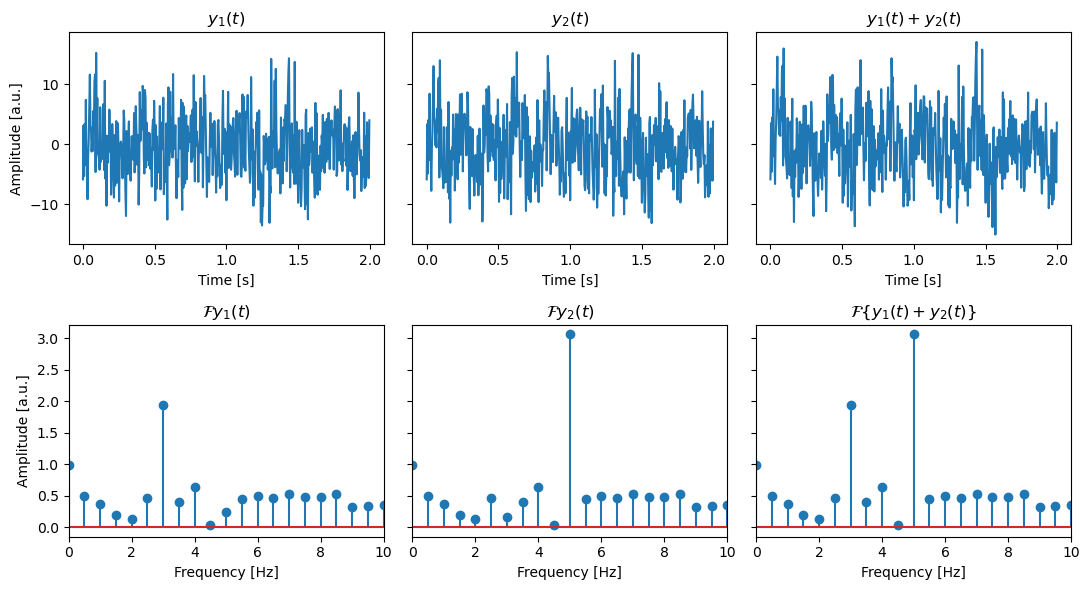

In [21]:
noise = np.random.randn(len(t))*5

fft_y1 = np.abs(np.fft.fft(y1+noise))[:len(t)//2] * 2/len(t)  # amplitude spectrum
fft_y2 = np.abs(np.fft.fft(y2+noise))[:len(t)//2] * 2/len(t)
fft_y1y2 = np.abs(np.fft.fft(y1+y2+noise))[:len(t)//2] * 2/len(t)  # amplitude spectrum

fig, ax = plt.subplots(2, 3, sharex="row", sharey="row", figsize=(11, 6))
ax[0, 0].plot(t, y1+noise)
ax[0, 1].plot(t, y2+noise)
ax[0, 2].plot(t, y1+y2+noise)
ax[0, 0].set(xlabel="Time [s]", ylabel="Amplitude [a.u.]", title="$y_1(t)$")
ax[0, 1].set(xlabel="Time [s]", title="$y_2(t)$");
ax[0, 2].set(xlabel="Time [s]", title="$y_1(t)+y_2(t)$")
ax[1, 0].stem(freq, fft_y1)
ax[1, 1].stem(freq, fft_y2)
ax[1, 2].stem(freq, fft_y1y2)
ax[1, 0].set(xlim=(0,10), xlabel="Frequency [Hz]", ylabel="Amplitude [a.u.]", title="$\mathcal{F}{y_1(t)}$")
ax[1, 1].set(xlim=(0,10), xlabel="Frequency [Hz]", title="$\mathcal{F}{y_2(t)}$")
ax[1, 2].set(xlim=(0,10), xlabel="Frequency [Hz]", title="$\mathcal{F}\{y_1(t) + y_2(t)\}$")
plt.tight_layout()

The frequency domain representation of a signal is less sensitive to (white) noise.

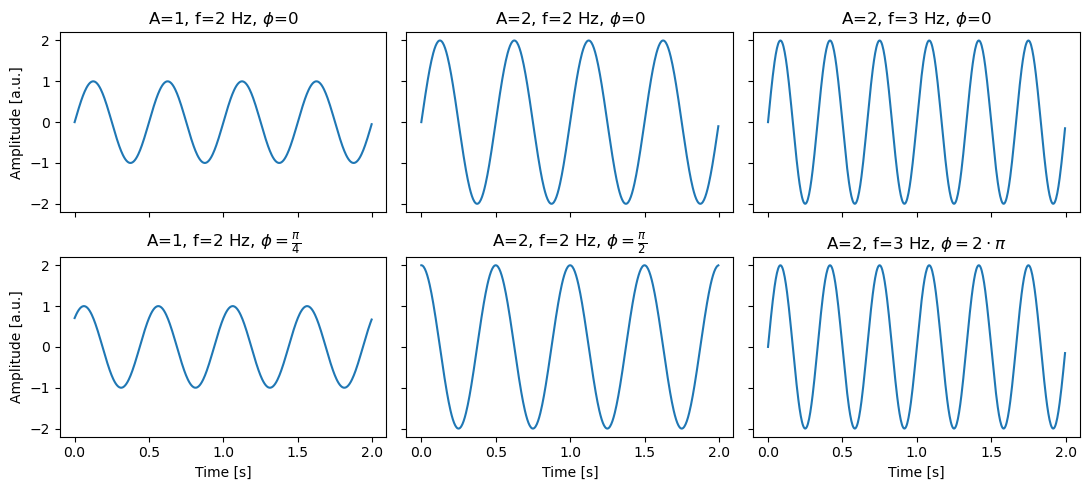

In [22]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 2, 500, endpoint=False)

fig, ax = plt.subplots(2, 3, figsize=(11, 5), sharex=True, sharey=True)

ax[0, 0].plot(t, 1 * np.sin(2 * np.pi * 2 * t))
ax[0, 0].set(title='A=1, f=2 Hz, $\phi$=0')

ax[0, 1].plot(t, 2 * np.sin(2 * np.pi * 2 * t))
ax[0, 1].set(title='A=2, f=2 Hz, $\phi$=0')

ax[0, 2].plot(t, 2 * np.sin(2 * np.pi * 3 * t))
ax[0, 2].set(title='A=2, f=3 Hz, $\phi$=0')

ax[1, 0].plot(t, 1 * np.sin(2 * np.pi * 2 * t + np.pi/4))
ax[1, 0].set(title='A=1, f=2 Hz, $\phi=\\frac{\pi}{4}$')

ax[1, 1].plot(t, 2 * np.sin(2 * np.pi * 2 * t + np.pi/2))
ax[1, 1].set(title='A=2, f=2 Hz, $\phi=\\frac{\pi}{2}$')

ax[1, 2].plot(t, 2 * np.sin(2 * np.pi * 3 * t + 2*np.pi))
ax[1, 2].set(title='A=2, f=3 Hz, $\phi=2 \cdot \pi$')

ax[0, 0].set(ylabel='Amplitude [a.u.]')
ax[1, 0].set(ylabel='Amplitude [a.u.]', xlabel='Time [s]')
ax[1, 1].set(xlabel='Time [s]')
ax[1, 2].set(xlabel='Time [s]')

plt.tight_layout()


We can think of the Fourier transform as a decomposition of the signal into multiple sine waves of the shape

$$A \cdot \sin(2\pi \cdot f \cdot t + \phi)$$

where $f$ is the **frequency** and $\phi$ the **phase** of the sine wave





(np.float64(-0.0998),
 np.float64(2.0958),
 np.float64(-6.451598952984399),
 np.float64(6.366941875257231))

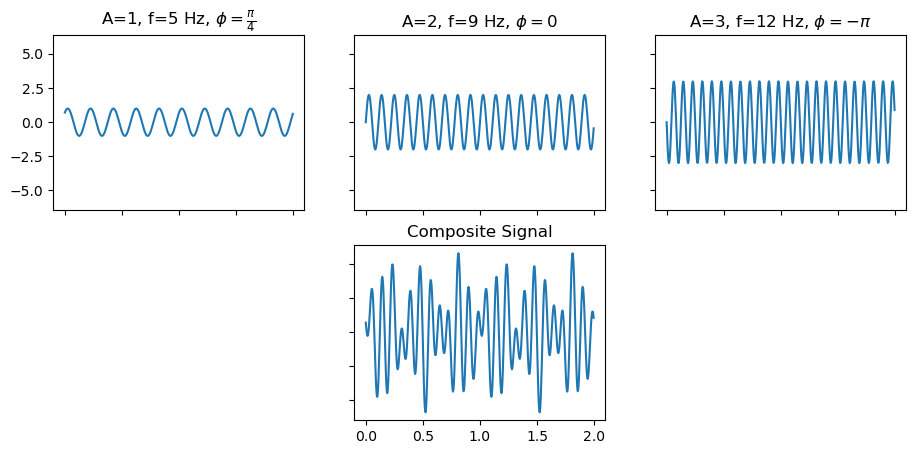

In [43]:

fig, ax = plt.subplots(2, 3, figsize=(11, 5), sharex=True, sharey=True)

s1 = 1 * np.sin(2 * np.pi * 5 * t + np.pi/4)
ax[0, 0].plot(t, s1)
ax[0, 0].set(title='A=1, f=5 Hz, $\phi=\\frac{\pi}{4}$')

s2 = 2 * np.sin(2 * np.pi * 9 * t)
ax[0, 1].plot(t, s2)
ax[0, 1].set(title='A=2, f=9 Hz, $\phi=0$')

s3 = 3 * np.sin(2 * np.pi * 12 * t + -np.pi)
ax[0, 2].plot(t, s3)
ax[0, 2].set(title='A=3, f=12 Hz, $\phi=-\pi$')


s = s1+s2+s3
ax[1,1].plot(t, s )
ax[1, 1].set(title='Composite Signal')

ax[1,0].axis("off")
ax[1,2].axis("off")


Let's consider a composite signal made up of three sinusoids with different frequency, amplitude and phase.

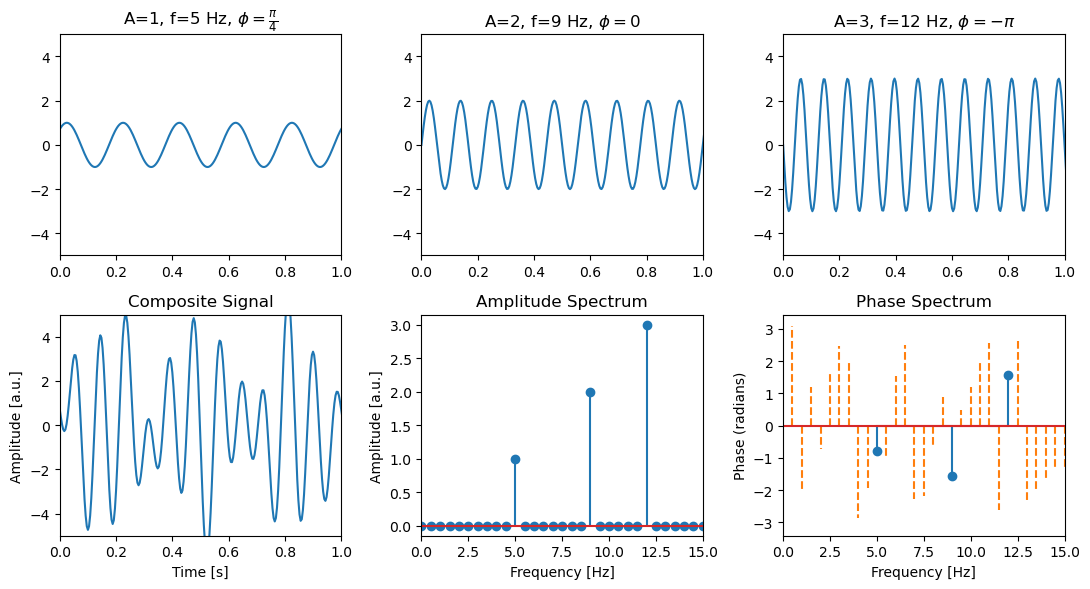

In [56]:
y = s
fft_y = np.fft.fft(y)[:len(t)//2]

amplitude = np.abs(fft_y) * 2/len(t)
phase = np.angle(fft_y)

fig, ax = plt.subplots(2,3 , figsize=(11, 6))


ax[0, 0].plot(t, s1)
ax[0, 0].set(title='A=1, f=5 Hz, $\phi=\\frac{\pi}{4}$', ylim=(-5, 5), xlim=(0, 1))

s2 = 2 * np.sin(2 * np.pi * 9 * t)
ax[0, 1].plot(t, s2)
ax[0, 1].set(title='A=2, f=9 Hz, $\phi=0$', ylim=(-5, 5), xlim=(0, 1))

s3 = 3 * np.sin(2 * np.pi * 12 * t + -np.pi)
ax[0, 2].plot(t, s3)
ax[0, 2].set(title='A=3, f=12 Hz, $\phi=-\pi$', ylim=(-5, 5), xlim=(0, 1))

ax[1, 0].plot(t, y)
ax[1, 0].set(title='Composite Signal', xlabel="Time [s]", ylabel="Amplitude [a.u.]", ylim=(-5, 5), xlim=(0, 1))

ax[1, 1].stem(freq, amplitude)
ax[1, 1].set(title='Amplitude Spectrum',xlabel='Frequency [Hz]', ylabel="Amplitude [a.u.]", xlim=(0,15))

threshold = 0.1
significant = amplitude > threshold
ax[1, 2].stem(freq[significant], phase[significant])
ax[1, 2].stem(freq[~significant], phase[~significant], linefmt="C1--", markerfmt="none")
ax[1, 2].set(title='Phase Spectrum', xlabel='Frequency [Hz]', ylabel='Phase (radians)', xlim=(0, 15))
plt.tight_layout()



$$y(t) = \sum_{k} A_k \sin(2\pi f_k t + \phi_k)$$

/tmp/ipykernel_258970/3476674324.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1, 1].legend()


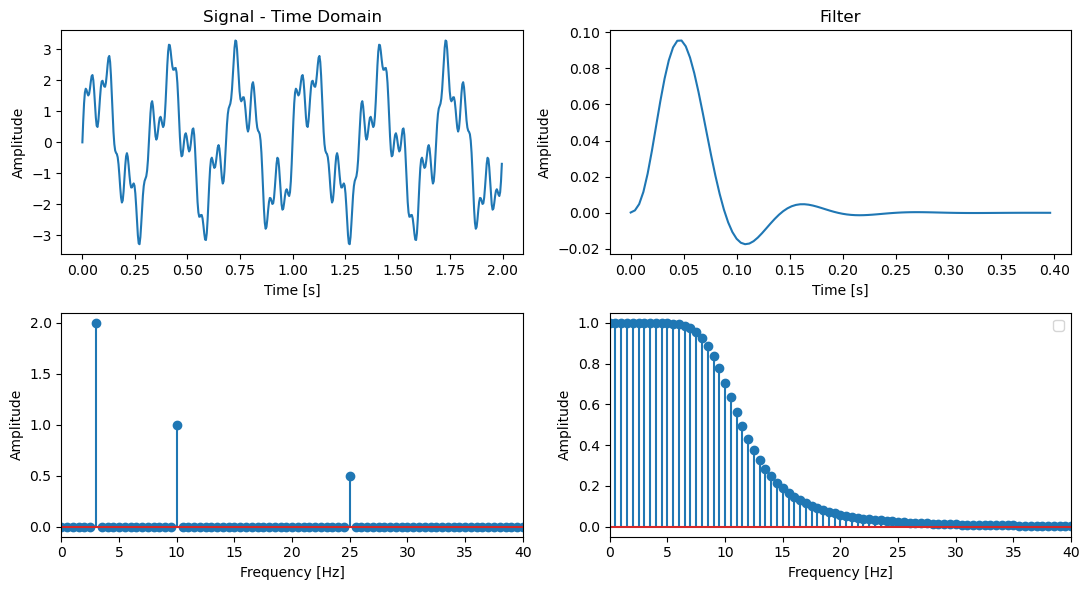

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig

# Parameters
fs = 250  # sampling rate
dur = 2
t = np.linspace(0, dur, fs * dur, endpoint=False)
freq = np.fft.fftfreq(len(t), 1/fs)[:len(t)//2]

# Create signal: sum of 3 Hz, 10 Hz, and 25 Hz
s = (2 * np.sin(2 * np.pi * 3 * t) + 
     1 * np.sin(2 * np.pi * 10 * t) + 
     0.5 * np.sin(2 * np.pi * 25 * t))

order = 4
cutoff = 10
b, a = sig.butter(order, cutoff, btype='low', fs=fs)
impulse = sig.unit_impulse(len(t))
filter_ir = sig.lfilter(b, a, impulse)

fft_signal = np.abs(np.fft.fft(s))[:len(t)//2] * 2/len(t)
fft_filter = np.abs(np.fft.fft(filter_ir))[:len(t)//2]

fig, ax = plt.subplots(2, 2, figsize=(11, 6))

ax[0, 0].plot(t, s)
ax[0, 0].set(xlabel='Time [s]', ylabel='Amplitude', title='Signal - Time Domain')

ax[1, 0].stem(freq, fft_signal)
ax[1, 0].set(xlabel='Frequency [Hz]', ylabel='Amplitude', xlim=(0, 40))

ax[0, 1].plot(t[:100], filter_ir[:100])
ax[0, 1].set(xlabel='Time [s]', ylabel='Amplitude', title='Filter')

ax[1, 1].stem(freq, fft_filter)
ax[1, 1].set(xlabel='Frequency [Hz]', ylabel='Amplitude', xlim=(0, 40))
ax[1, 1].legend()

plt.tight_layout()
